# Lab 11 — Deploy de Modelos de Visão Computacional

## Objetivos
1. Carregar um modelo pré-treinado do torchvision
2. Realizar inferência local em imagens
3. Entender a estrutura da API FastAPI do lab
4. Testar o endpoint `/predict` via código Python

---

**Não há treinamento neste lab.** O foco é o **deploy** de um modelo já treinado.

In [2]:
# Instalar dependências (apenas uma vez)
%pip install torch torchvision pillow requests matplotlib

  Using cached setuptools-83.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-macosx_10_13_universal2.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.2/111.2 MB 45.3 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 43.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 47.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 44.3 MB/s  0:00:00m0:00:01
Using cached contourpy-1.3.3-cp312

## Parte 1 — Inferência local com modelo pré-treinado

In [3]:
import torch
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import urllib.request

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando: {device}')

Matplotlib is building the font cache; this may take a moment.


Usando: cpu


In [4]:
# Carrega MobileNetV3-Small com pesos ImageNet
# O torchvision faz o download automático (~10 MB) na primeira execução
model = models.mobilenet_v3_small(weights='IMAGENET1K_V1')
model.eval()
model = model.to(device)

print(f'Parâmetros totais: {sum(p.numel() for p in model.parameters()):,}')

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /Users/arnaldoalvesvianajunior/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100.0%


Parâmetros totais: 2,542,856


In [5]:
# Baixar os rótulos das 1000 classes do ImageNet
url = 'https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt'
urllib.request.urlretrieve(url, 'imagenet_classes.txt')

with open('imagenet_classes.txt') as f:
    classes = [line.strip() for line in f.readlines()]

print(f'Total de classes: {len(classes)}')
print('Exemplo de classes:', classes[281], '|', classes[0], '|', classes[999])

Total de classes: 1000
Exemplo de classes: tabby | tench | toilet tissue


In [6]:
# Pré-processamento padrão para modelos ImageNet
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

def inferir(caminho_imagem: str) -> list[tuple[str, float]]:
    """Retorna top-3 classes e probabilidades para uma imagem."""
    img = Image.open(caminho_imagem).convert('RGB')
    tensor = preprocess(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor)
        probs = torch.softmax(logits, dim=1)[0]

    top_probs, top_indices = torch.topk(probs, k=3)
    return [(classes[i], round(p.item(), 4)) for i, p in zip(top_indices, top_probs)]

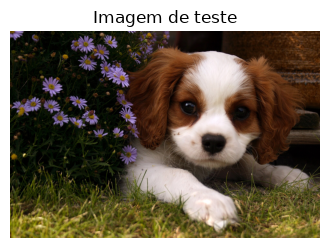


Top-3 previsões:
  Blenheim spaniel                99.8%
  Welsh springer spaniel          0.1%
  papillon                        0.0%


In [11]:
imgem_teste = "/Users/arnaldoalvesvianajunior/computervision/visao_computacional/docs/aulas/lab11/teste.png"
# Exibir imagem
img = Image.open(imgem_teste)

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis('off')
plt.title('Imagem de teste')
plt.show()

# Inferir
resultado = inferir(imgem_teste)
print('\nTop-3 previsões:')
for classe, prob in resultado:
    print(f'  {classe:30s}  {prob*100:.1f}%')

---
## Parte 2 — Estrutura da API

Abra e leia os arquivos `app.py` e `model.py` do lab.
Responda:

1. Qual função é chamada no startup da aplicação?
2. Qual endpoint recebe a imagem? Qual método HTTP ele usa?
3. O que `preprocess_image()` faz com a imagem antes de passá-la ao modelo?
4. O que acontece se o arquivo enviado não for uma imagem válida?

---
## Parte 3 — Testando a API via código

**Pré-requisito:** o servidor deve estar rodando.

```bash
uvicorn app:app --reload
```

In [14]:
import requests
import json

URL = 'http://localhost:8000/predict'

with open(imgem_teste, 'rb') as f:
    response = requests.post(URL, files={'file': (imgem_teste, f, 'image/jpeg')})

print(f'Status: {response.status_code}')
print(json.dumps(response.json(), indent=2, ensure_ascii=False))

ConnectionError: HTTPConnectionPool(host='localhost', port=8000): Max retries exceeded with url: /predict (Caused by NewConnectionError("HTTPConnection(host='localhost', port=8000): Failed to establish a new connection: [Errno 61] Connection refused"))

In [ ]:
# Verificar o health check da API
resp = requests.get('http://localhost:8000/health')
print(json.dumps(resp.json(), indent=2, ensure_ascii=False))

---
## Exercícios

1. **Troque o modelo:** substitua `mobilenet_v3_small` por `resnet18` em `model.py`. Compare os resultados e a velocidade de resposta.

2. **Teste com suas imagens:** envie pelo menos 5 imagens diferentes e anote as previsões. O modelo acertou? Em quais casos errou?

3. **Novo endpoint `/predict/batch`:** modifique `app.py` para aceitar uma lista de arquivos e retornar uma lista de previsões.

4. **CP1 — preview:** comece a pensar em qual classificador você vai fazer o deploy para o CP1. Pode ser uma CNN (lab10) ou um Vision Transformer (lab13).